In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA — Overview
This notebook performs exploratory data analysis for the credit risk dataset.

**Structure (matches Streamlit app):**
- Univariate — single-variable distributions and counts
- Bivariate — relationships between pairs of variables (scatter, grouped bars, boxplots)
- Correlation / Multivariate — heatmap and grouped analyses

Run the cells below in order. The sections are intentionally separated so you can copy them into the Streamlit app (or refer to the app tabs).

In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')

# --- sanitize `person_age` so notebook matches the app (integers 1..100) ---
if 'person_age' in df.columns:
    df['person_age'] = pd.to_numeric(df['person_age'], errors='coerce')
    df['person_age'] = df['person_age'].clip(1, 100)
    if df['person_age'].isna().any():
        med = int(df['person_age'].median(skipna=True)) if not np.isnan(df['person_age'].median(skipna=True)) else 30
        df['person_age'].fillna(med, inplace=True)
    df['person_age'] = df['person_age'].astype(int)

# --- ensure `person_income` and `loan_amnt` are integers ---
for _col in ['person_income','loan_amnt']:
    if _col in df.columns:
        df[_col] = pd.to_numeric(df[_col], errors='coerce')
        medv = df[_col].median(skipna=True)
        if np.isnan(medv):
            medv = 0
        df[_col].fillna(int(medv), inplace=True)
        df[_col] = df[_col].round().astype(int)

# show head
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
isnull = df.isnull().sum()
isnull

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
df.info

<bound method DataFrame.info of        person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amn

In [7]:
df['person_emp_length'].fillna(df['person_emp_length'].mean(), inplace=True)

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\1498371852.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].mean(), inplace=True)


In [8]:
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)    

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\3473392750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)


In [9]:
df = df[df['person_age'] < 80]
df= df[df['person_emp_length'] < 50]

In [10]:
isnull = df.isnull().sum()
isnull

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## Univariate analysis

Single-variable plots to inspect distributions and class balance. Use these to detect skew, outliers and class imbalance before modeling.

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\757800802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="loan_intent", data=df, order=df["loan_intent"].value_counts().index, palette="viridis")


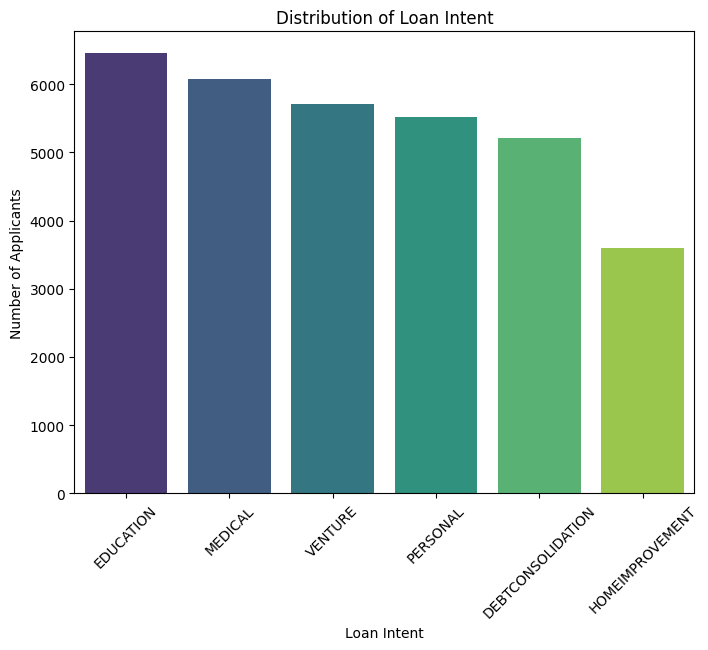

In [11]:
# Plot loan intent distribution
plt.figure(figsize=(8,6))
sns.countplot(x="loan_intent", data=df, order=df["loan_intent"].value_counts().index, palette="viridis")

plt.title("Distribution of Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()


C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\717180172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="person_home_ownership", data=df,


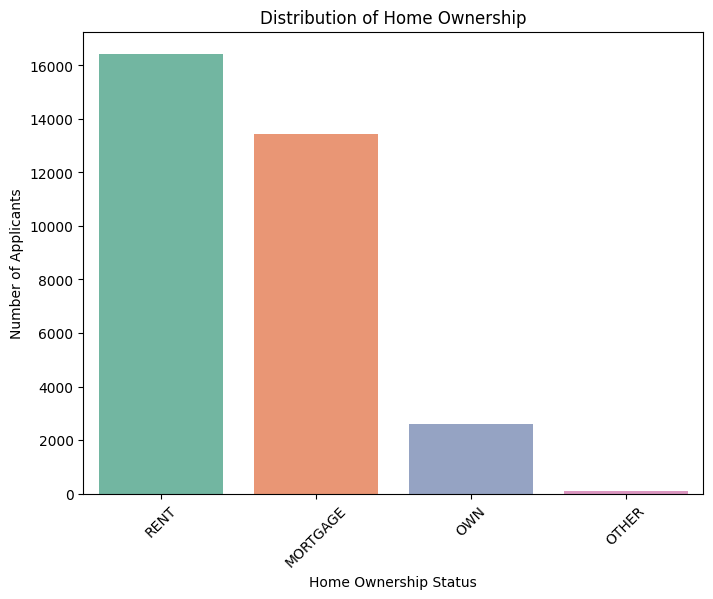

In [12]:
# Plot home ownership distribution
plt.figure(figsize=(8,6))
sns.countplot(x="person_home_ownership", data=df, 
              order=df["person_home_ownership"].value_counts().index, 
              palette="Set2")

plt.title("Distribution of Home Ownership")
plt.xlabel("Home Ownership Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=45)
plt.show()


## Bivariate analysis

Plots showing relationships between two variables (e.g., income vs loan amount, debt-to-income vs loan amount, grouped barplots by category).

C:\Users\yashs\AppData\Local\Temp\ipykernel_18632\3064800262.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="age_group", y="loan_amnt", data=df, palette="Set3")


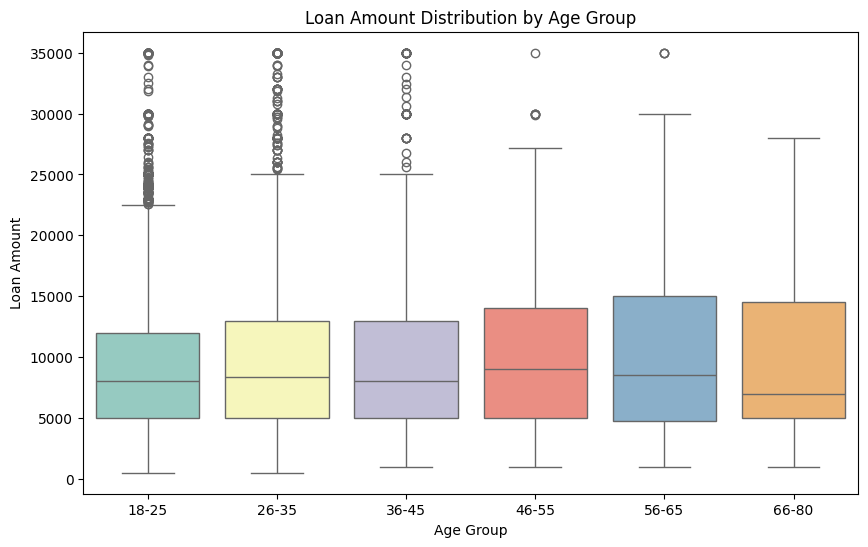

In [ ]:
# Create age groups (updated to cover 1–100)
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[1,18,25,35,45,55,65,80,100],
    labels=["1-18","19-25","26-35","36-45","46-55","56-65","66-80","81-100"]
)

plt.figure(figsize=(10,6))
sns.boxplot(x="age_group", y="loan_amnt", data=df, palette="Set3")

plt.title("Loan Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Loan Amount")
plt.show()

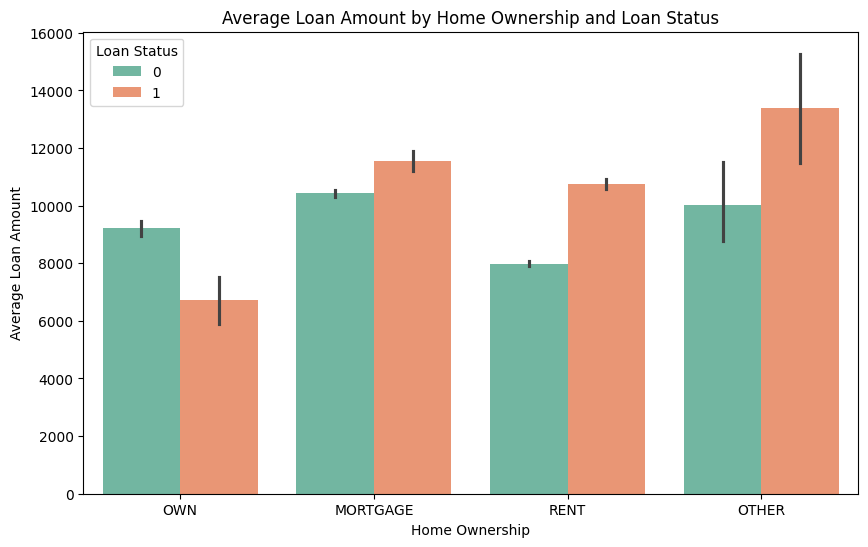

In [15]:
# Grouped bar plot: Loan Amount by Home Ownership and Loan Status
plt.figure(figsize=(10,6))
sns.barplot(x="person_home_ownership", y="loan_amnt", hue="loan_status",data=df, estimator=lambda x: sum(x)/len(x), palette="Set2")

plt.title("Average Loan Amount by Home Ownership and Loan Status")
plt.xlabel("Home Ownership")
plt.ylabel("Average Loan Amount")
plt.legend(title="Loan Status")
plt.show()


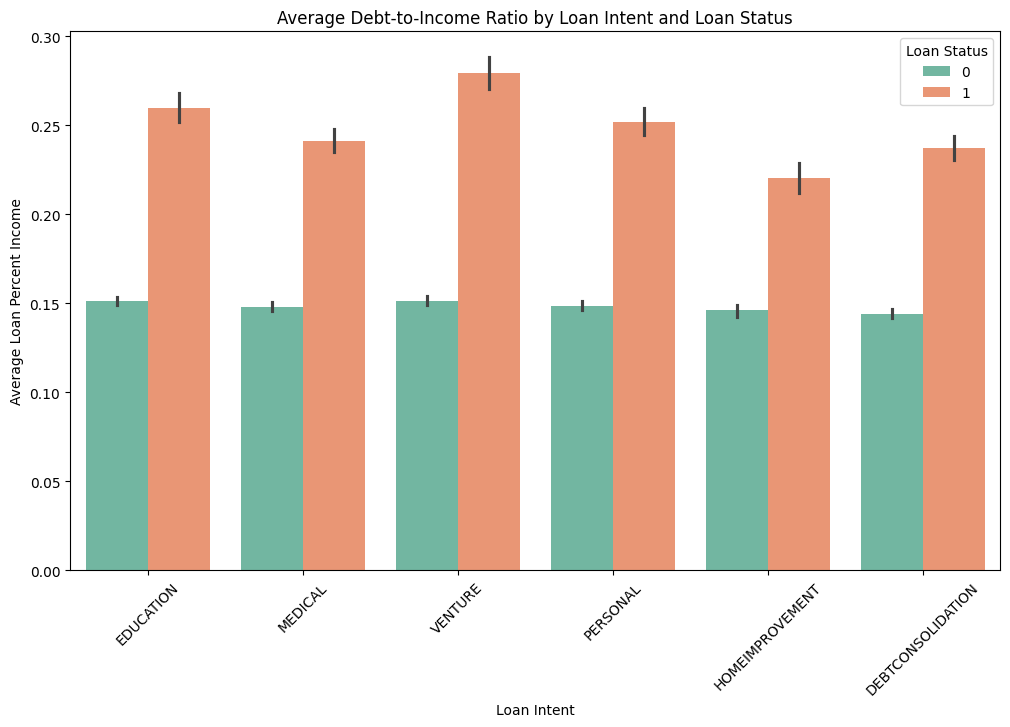

In [19]:
plt.figure(figsize=(12,7))
sns.barplot(x="loan_intent", y="loan_percent_income", 
            hue="loan_status", data=df, 
            estimator=lambda x: sum(x)/len(x), palette="Set2")

plt.title("Average Debt-to-Income Ratio by Loan Intent and Loan Status")
plt.xlabel("Loan Intent")
plt.ylabel("Average Loan Percent Income")
plt.xticks(rotation=45)
plt.legend(title="Loan Status")
plt.show()


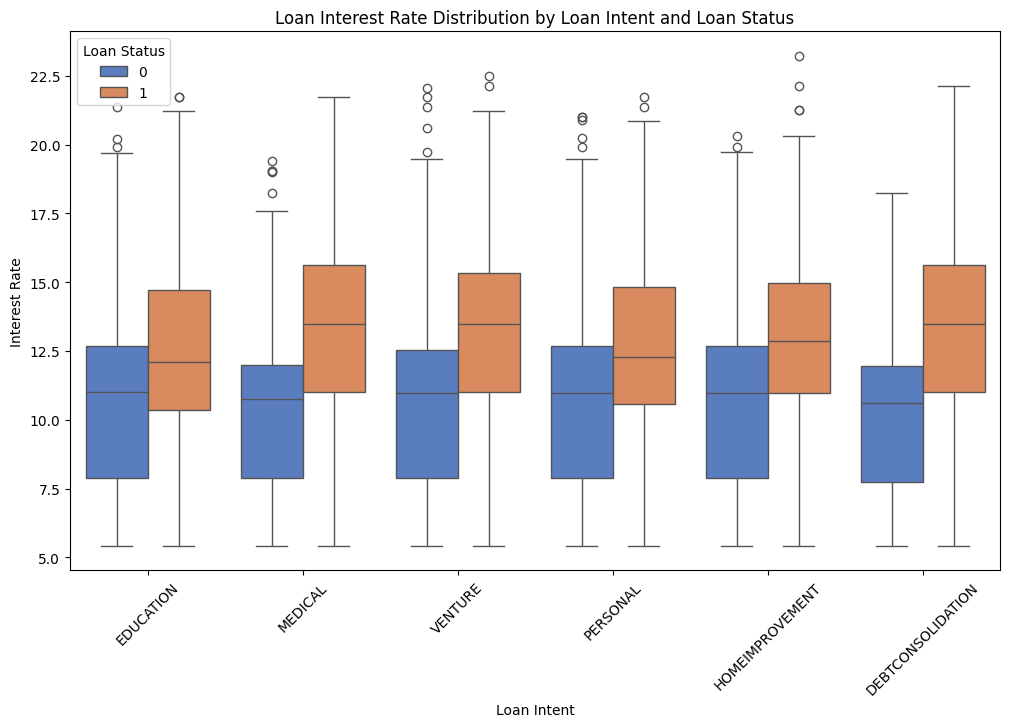

In [20]:
plt.figure(figsize=(12,7))
sns.boxplot(x="loan_intent", y="loan_int_rate", 
            hue="loan_status", data=df, palette="muted")

plt.title("Loan Interest Rate Distribution by Loan Intent and Loan Status")
plt.xlabel("Loan Intent")
plt.ylabel("Interest Rate")
plt.xticks(rotation=45)
plt.legend(title="Loan Status")
plt.show()


## Correlation / Multivariate analysis

Heatmap and grouped analyses to inspect multivariate relationships and feature correlations (useful for feature selection and multicollinearity checks).

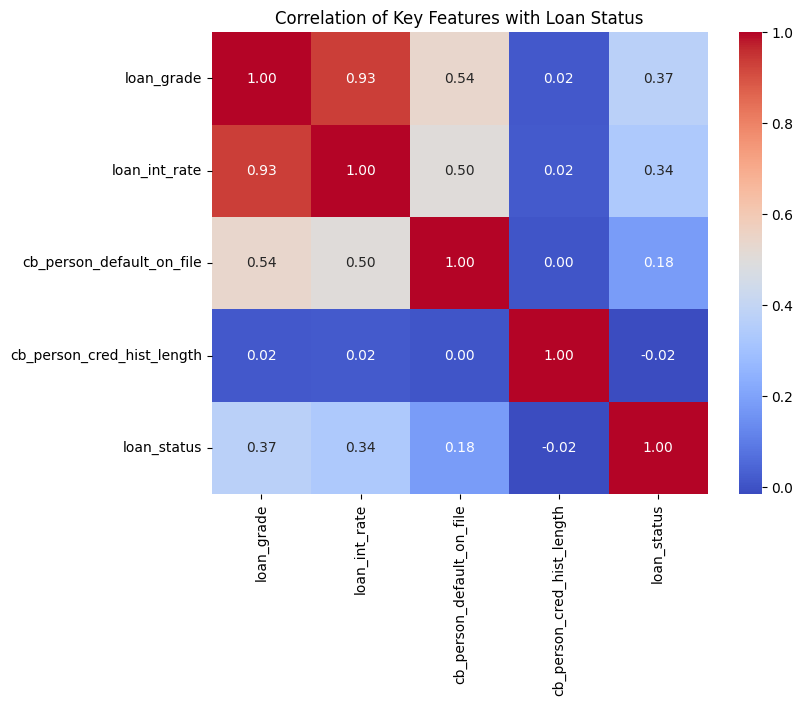

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("credit_risk_dataset.csv")

# Encode categorical features
df_encoded = df.copy()
df_encoded["loan_grade"] = df_encoded["loan_grade"].astype("category").cat.codes
df_encoded["cb_person_default_on_file"] = df_encoded["cb_person_default_on_file"].map({"Y":1,"N":0})

# Rename the typo column for clarity
df_encoded = df_encoded.rename(columns={"cb_preson_cred_hist_length": "credit_hist_length"})

# Select relevant features
features = ["loan_grade", "loan_int_rate", "cb_person_default_on_file", "cb_person_cred_hist_length", "loan_status"]

# Correlation matrix
corr = df_encoded[features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Key Features with Loan Status")
plt.show()


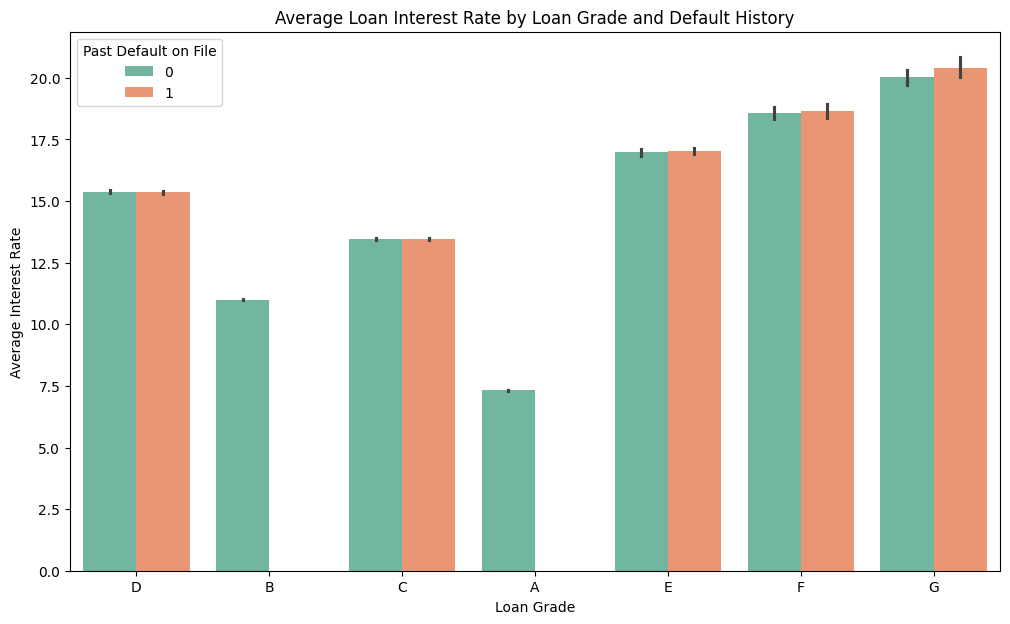

In [22]:
# Encode categorical features
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({"Y":1,"N":0})

plt.figure(figsize=(12,7))
sns.barplot(x="loan_grade", y="loan_int_rate", 
            hue="cb_person_default_on_file", data=df, 
            estimator=lambda x: sum(x)/len(x), palette="Set2")

plt.title("Average Loan Interest Rate by Loan Grade and Default History")
plt.xlabel("Loan Grade")
plt.ylabel("Average Interest Rate")
plt.legend(title="Past Default on File")
plt.show()


In [24]:
df.to_csv("clean_data.csv", index = False)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,0,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,0,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,0,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,0,26


In [2]:
df['person_income'].max()

NameError: name 'df' is not defined